In [2]:
import os, glob, scipy.io, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import cv2

# ── Download Penn Action dataset from Kaggle ──────────────────────────────
import subprocess, sys

# 1. Install kaggle CLI
subprocess.run([sys.executable, '-m', 'pip', 'install', 'kaggle', '-q'], check=True)

# 2. Upload kaggle.json credentials
#    Run this block ONCE. When the file-picker appears, select your kaggle.json.
from google.colab import files as colab_files
print("Upload your kaggle.json (from kaggle.com → Account → API → Create New Token)")
uploaded = colab_files.upload()   # shows file picker

import os
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 3. Download & unzip (~600 MB, takes ~2 min on Colab)
DOWNLOAD_DIR = "/content/penn_action"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
subprocess.run([
    "kaggle", "datasets", "download",
    "kaushalbora18/penn-action-dataset",
    "-p", DOWNLOAD_DIR, "--unzip"
], check=True)

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR   = os.path.join(DOWNLOAD_DIR, "Penn_Action")
LABELS_DIR = os.path.join(DATA_DIR, "labels")
FRAMES_DIR = os.path.join(DATA_DIR, "frames")

print(f"Data dir exists   : {os.path.exists(DATA_DIR)}")
print(f"Labels dir exists : {os.path.exists(LABELS_DIR)}")
print(f"Frames dir exists : {os.path.exists(FRAMES_DIR)}")


Upload your kaggle.json (from kaggle.com → Account → API → Create New Token)


Saving kaggle.json to kaggle.json
Data dir exists   : True
Labels dir exists : True
Frames dir exists : True


In [3]:
# Lấy danh sách tất cả file .mat
mat_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))
data_info = []

for mat_file in mat_files:
    video_id = os.path.basename(mat_file).replace('.mat', '')

    try:
        # Load file mat
        mat_content = scipy.io.loadmat(mat_file)

        # Trích xuất nhãn hành động (xử lý định dạng chuỗi trong file mat)
        action = mat_content['action'][0] if 'action' in mat_content else 'unknown'
        if isinstance(action, np.ndarray) and len(action) > 0:
            action = action[0]

        # Trích xuất số lượng khung hình
        nframes = mat_content['nframes'][0][0] if 'nframes' in mat_content else 0

        data_info.append({
            'video_id': video_id,
            'action': str(action),
            'nframes': int(nframes)
        })
    except Exception as e:
        print(f"Lỗi đọc file {video_id}: {e}")

df = pd.DataFrame(data_info)
print(f"Tổng số video quét được: {len(df)}")
df.head()

Tổng số video quét được: 2326


,video_id,action,nframes
0,0001,baseball_pitch,151
1,0002,baseball_pitch,80
2,0003,baseball_pitch,85
3,0004,baseball_pitch,82
4,0005,baseball_pitch,48


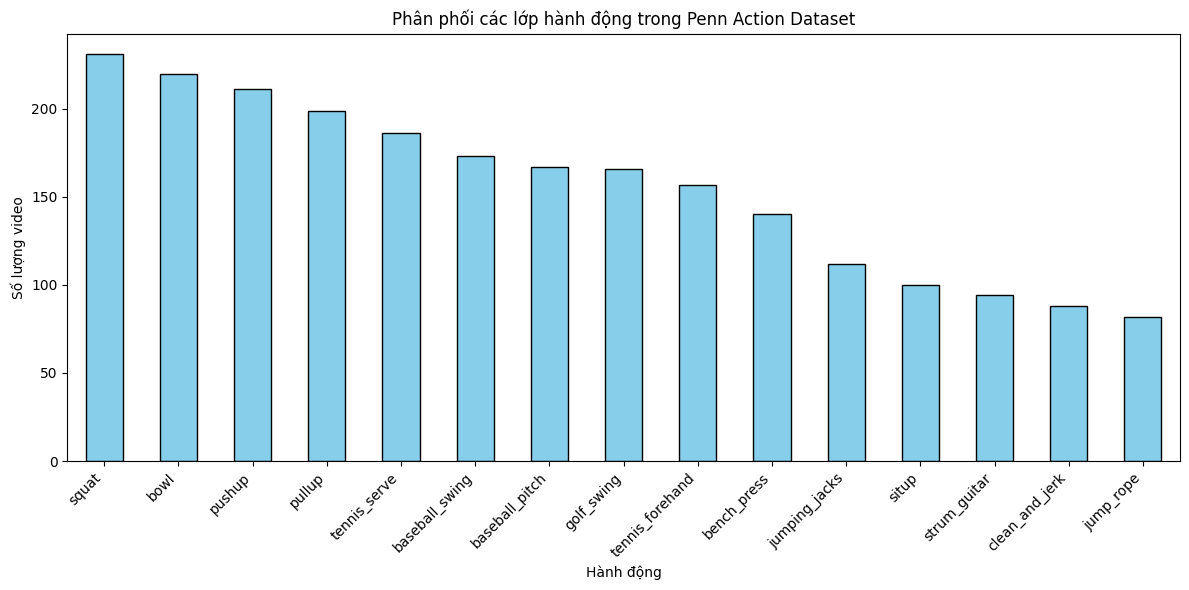


Số lượng video thuộc nhóm tập thể dục: 1163 / 2326
Chi tiết số lượng từng bài tập:
action
squat             231
pushup            211
pullup            199
bench_press       140
jumping_jacks     112
situp             100
clean_and_jerk     88
jump_rope          82
Name: count, dtype: int64

Số khung hình trung bình: 83.3
Số khung hình ít nhất: 18
Số khung hình nhiều nhất: 663


In [4]:
# 1. Vẽ biểu đồ phân phối toàn bộ hành động
plt.figure(figsize=(12, 6))
df['action'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Phân phối các lớp hành động trong Penn Action Dataset')
plt.xlabel('Hành động')
plt.ylabel('Số lượng video')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Lọc subset các bài tập thể dục (Exercise subset)
# Tham khảo các nhãn có trong Penn Action
exercise_classes = [
    'bench_press', 'clean_and_jerk', 'jump_rope',
    'jumping_jacks', 'pullup', 'pushup', 'situp', 'squat'
]

df_exercise = df[df['action'].isin(exercise_classes)].copy()

print(f"\nSố lượng video thuộc nhóm tập thể dục: {len(df_exercise)} / {len(df)}")
print("Chi tiết số lượng từng bài tập:")
print(df_exercise['action'].value_counts())

# Phân tích độ dài khung hình (quan trọng cho ST-GCN)
print(f"\nSố khung hình trung bình: {df_exercise['nframes'].mean():.1f}")
print(f"Số khung hình ít nhất: {df_exercise['nframes'].min()}")
print(f"Số khung hình nhiều nhất: {df_exercise['nframes'].max()}")

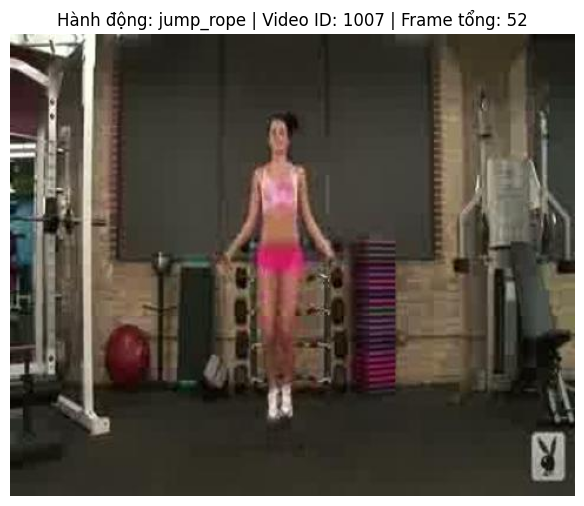

In [5]:
# Chọn ngẫu nhiên 1 video từ nhóm tập thể dục
sample_row = df_exercise.sample(1).iloc[0]
sample_vid = sample_row['video_id']
sample_action = sample_row['action']

# Đường dẫn đến thư mục chứa frames của video đó
sample_frames_dir = os.path.join(FRAMES_DIR, sample_vid)
frame_files = sorted(glob.glob(os.path.join(sample_frames_dir, '*.jpg')))

if len(frame_files) > 0:
    # Đọc frame ở giữa video (thường là khoảnh khắc động tác rõ nhất)
    mid_frame_path = frame_files[len(frame_files) // 2]
    img = cv2.imread(mid_frame_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Hành động: {sample_action} | Video ID: {sample_vid} | Frame tổng: {len(frame_files)}")
    plt.axis('off')
    plt.show()
else:
    print(f"Không tìm thấy ảnh nào trong thư mục {sample_frames_dir}")

Using video: 0341  action: bench_press  frame: 21/40


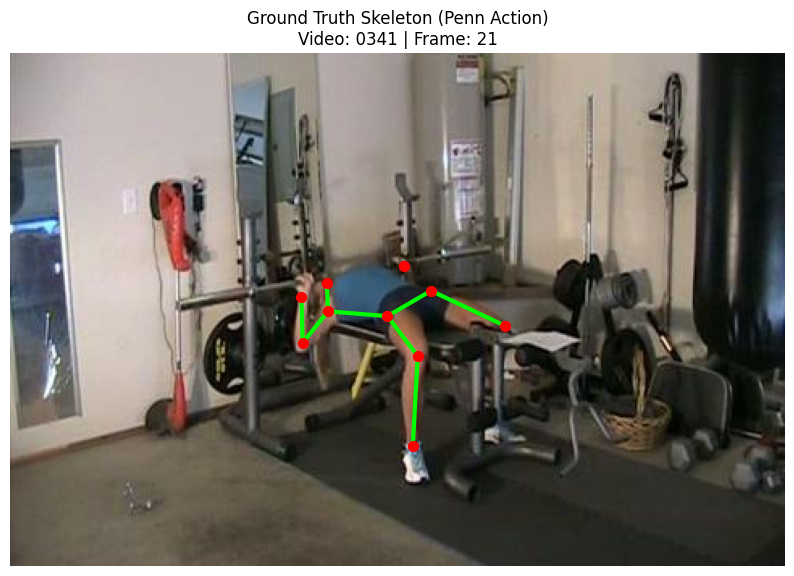

In [6]:
import os
import cv2
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Bone pairs for 13 Penn Action joints
# 0:head, 1:l_sho, 2:r_sho, 3:l_elb, 4:r_elb, 5:l_wri, 6:r_wri,
# 7:l_hip, 8:r_hip, 9:l_kne, 10:r_kne, 11:l_ank, 12:r_ank
penn_action_bones = [
    (0,1),(0,2),(1,3),(3,5),(2,4),(4,6),
    (1,7),(2,8),(7,8),(7,9),(9,11),(8,10),(10,12)
]

# ── Auto-pick first exercise video that has readable frames ───────────────
exercise_classes = [
    "bench_press","clean_and_jerk","jump_rope","jumping_jacks",
    "pullup","pushup","situp","squat"
]

video_id, frame_idx, img, mat_data = None, None, None, None

for mat_file in sorted(glob.glob(os.path.join(LABELS_DIR, "*.mat"))):
    try:
        m = scipy.io.loadmat(mat_file)
        action = m["action"][0]
        if isinstance(action, np.ndarray): action = action[0]
        if str(action) not in exercise_classes:
            continue
        vid = os.path.basename(mat_file).replace(".mat", "")
        frames_dir = os.path.join(FRAMES_DIR, vid)
        frame_files = sorted(glob.glob(os.path.join(frames_dir, "*.jpg")))
        if not frame_files:
            continue
        # pick middle frame
        mid = len(frame_files) // 2
        candidate = cv2.imread(frame_files[mid])
        if candidate is None:
            continue
        # found a valid video
        video_id  = vid
        frame_idx = mid
        img       = candidate
        mat_data  = m
        print(f"Using video: {video_id}  action: {action}  frame: {frame_idx+1}/{len(frame_files)}")
        break
    except Exception:
        continue

if img is None:
    raise RuntimeError("No readable video frames found — check FRAMES_DIR path.")

img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
x_coords   = mat_data["x"][frame_idx]
y_coords   = mat_data["y"][frame_idx]
visibility = mat_data["visibility"][frame_idx]

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)

for partA, partB in penn_action_bones:
    if visibility[partA] > 0 and visibility[partB] > 0:
        plt.plot([x_coords[partA], x_coords[partB]],
                 [y_coords[partA], y_coords[partB]],
                 color="lime", linewidth=3)

for i in range(len(x_coords)):
    if visibility[i] > 0:
        plt.scatter(x_coords[i], y_coords[i], color="red", s=50, zorder=5)

plt.title(f"""Ground Truth Skeleton (Penn Action)
Video: {video_id} | Frame: {frame_idx+1}""")
plt.axis("off")
plt.show()

In [7]:
import numpy as np

def add_virtual_center_joint(keypoints):
    """
    keypoints: mảng numpy có kích thước (Frames, 13, 2) chứa tọa độ X, Y
    """
    # Lấy tọa độ của 4 khớp tạo thành hình chữ nhật thân người
    l_sho, r_sho = keypoints[:, 1, :], keypoints[:, 2, :]
    l_hip, r_hip = keypoints[:, 7, :], keypoints[:, 8, :]

    # Tính trọng tâm (Trung bình cộng của 4 điểm)
    center_joint = (l_sho + r_sho + l_hip + r_hip) / 4.0

    # Mở rộng chiều để ghép vào mảng gốc: (Frames, 1, 2)
    center_joint = center_joint[:, np.newaxis, :]

    # Ghép khớp ảo vào cuối mảng gốc -> Kích thước mới: (Frames, 14, 2)
    new_keypoints = np.concatenate((keypoints, center_joint), axis=1)

    return new_keypoints

# Giả sử x_coords và y_coords (kích thước [Frames, 13]) lấy từ file .mat
# Tạo mảng dummy để test:
# dummy_frames = np.zeros((35, 13, 2))
# updated_frames = add_virtual_center_joint(dummy_frames)
# print(updated_frames.shape) # Kết quả: (35, 14, 2)

In [9]:
import torch
import numpy as np

class Graph_PennAction_14Nodes():
    def __init__(self):
        self.num_node = 14
        self.center_node = 13 # Khớp ảo vừa tạo làm trọng tâm

        # Cạnh cũ (13 khớp)
        self.edges = [
            (0, 1), (0, 2), (1, 3), (3, 5), (2, 4), (4, 6),
            (1, 7), (2, 8), (7, 8), (7, 9), (9, 11), (8, 10), (10, 12)
        ]

        # Thêm cạnh nối khớp ảo (13) với 4 góc của hình chữ nhật thân người
        self.edges.extend([(1, 13), (2, 13), (7, 13), (8, 13)])

        self.A = self.get_spatial_partition_matrix()

    def get_hop_distance(self):
        # Tính khoảng cách số bước nhảy (hop) giữa các khớp trên đồ thị
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edges:
            A[j, i] = 1
            A[i, j] = 1

        hop_dis = np.zeros((self.num_node, self.num_node)) + np.inf
        # Duyệt tối đa 14 bước để tìm đường đi ngắn nhất
        transfer_mat = [np.linalg.matrix_power(A, d) for d in range(self.num_node)]
        arrive_mat = (np.stack(transfer_mat) > 0)
        for d in range(self.num_node - 1, -1, -1):
            hop_dis[arrive_mat[d]] = d
        return hop_dis

    def get_spatial_partition_matrix(self):
        # Lấy ma trận khoảng cách
        hop_dis = self.get_hop_distance()

        # Tính khoảng cách từ tất cả các điểm về trọng tâm (Center node)
        node_traversal_rate = hop_dis[self.center_node]

        # Khởi tạo ma trận A với 3 luồng (3, 14, 14)
        A = np.zeros((3, self.num_node, self.num_node))

        for i, j in self.edges:
            # Luôn cho phép tự nối chính nó (Self-loop)
            A[0, i, i] = 1
            A[0, j, j] = 1

            # Chiến lược phân hoạch:
            if node_traversal_rate[i] > node_traversal_rate[j]:
                # j gần trọng tâm hơn i -> j là hướng tâm của i
                A[1, j, i] = 1
                A[2, i, j] = 1
            elif node_traversal_rate[i] < node_traversal_rate[j]:
                # i gần trọng tâm hơn j -> i là hướng tâm của j
                A[1, i, j] = 1
                A[2, j, i] = 1
            else:
                # Cùng khoảng cách đến trọng tâm
                A[0, i, j] = 1
                A[0, j, i] = 1

        # Chuẩn hóa ma trận (tránh bùng nổ gradient khi train)
        for i in range(3):
            D = np.diag(np.sum(A[i], axis=1))
            # Xử lý chia cho 0
            D_inv = np.zeros_like(D)
            D_inv[D > 0] = 1.0 / D[D > 0]
            A[i] = np.dot(A[i], D_inv)

        return torch.tensor(A, dtype=torch.float32)

# Test thử ma trận
graph = Graph_PennAction_14Nodes()
print(f"Kích thước ma trận kề A chuẩn: {graph.A.shape}")
# Kết quả mong đợi: torch.Size([3, 14, 14])

Kích thước ma trận kề A chuẩn: torch.Size([3, 14, 14])


## Visualizations
Các cell dưới đây được thêm vào để trực quan hóa đồ thị, dữ liệu, kiến trúc mô hình và kết quả huấn luyện.

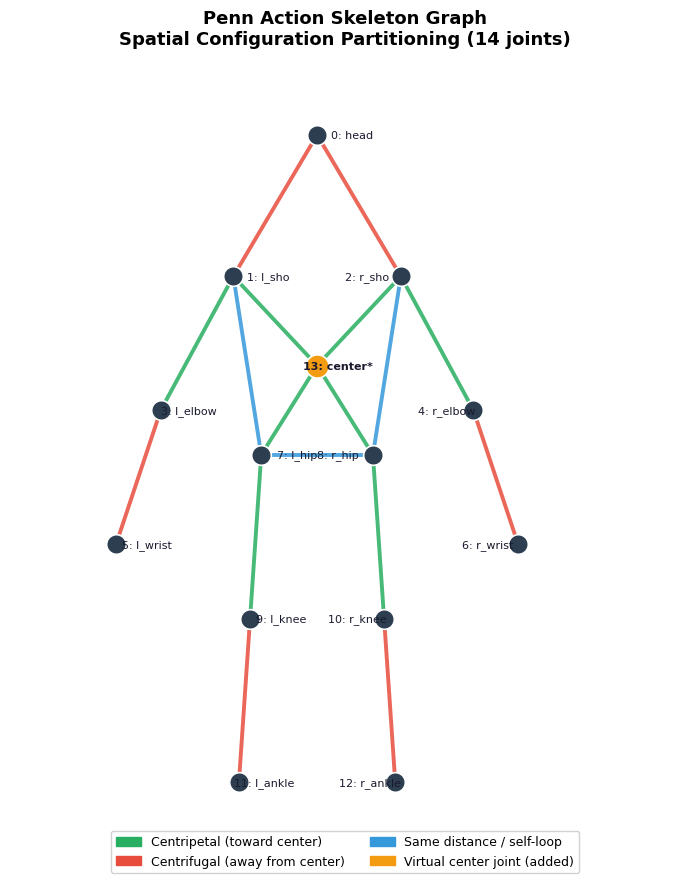

In [21]:
# ── VIZ-1a: Skeleton graph — colored by partition type ──────────────────────
# Reuses: graph (Graph_PennAction_14Nodes instance from cell above)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

JOINT_POS = {
    0:  (0.50, 0.95),  1:  (0.35, 0.76),  2:  (0.65, 0.76),
    3:  (0.22, 0.58),  4:  (0.78, 0.58),  5:  (0.14, 0.40),
    6:  (0.86, 0.40),  7:  (0.40, 0.52),  8:  (0.60, 0.52),
    9:  (0.38, 0.30), 10:  (0.62, 0.30), 11:  (0.36, 0.08),
   12:  (0.64, 0.08), 13:  (0.50, 0.64),
}
JOINT_NAMES = [
    'head','l_sho','r_sho','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle','center*'
]

A = graph.A.numpy()  # (3, 14, 14)

fig, ax = plt.subplots(figsize=(7, 9))
ax.set_xlim(-0.05, 1.15); ax.set_ylim(-0.05, 1.05); ax.axis('off')
ax.set_title('Penn Action Skeleton Graph\nSpatial Configuration Partitioning (14 joints)',
             fontsize=13, fontweight='bold', pad=12)

C_SAME = '#3498db'; C_IN = '#27ae60'; C_OUT = '#e74c3c'

for (i, j) in graph.edges:
    xi, yi = JOINT_POS[i]; xj, yj = JOINT_POS[j]
    color = C_IN if (A[1,j,i]>0 or A[1,i,j]>0) else C_OUT if (A[2,j,i]>0 or A[2,i,j]>0) else C_SAME
    ax.plot([xi, xj], [yi, yj], color=color, linewidth=2.8, zorder=1, alpha=0.85)

for idx, (x, y) in JOINT_POS.items():
    c = '#f39c12' if idx == 13 else '#2c3e50'
    ax.scatter(x, y, s=280 if idx==13 else 200, color=c, zorder=3,
               edgecolors='white', linewidths=1.2)
    ha = 'right' if x <= 0.5 else 'left'
    ax.text(x + (0.1001 if x<=0.5 else -0.1001), y, f'{idx}: {JOINT_NAMES[idx]}',
            fontsize=8, va='center', ha=ha, zorder=4, color='#1a1a2e',
            fontweight='bold' if idx==13 else 'normal')

patches = [
    mpatches.Patch(color=C_IN,      label='Centripetal (toward center)'),
    mpatches.Patch(color=C_OUT,     label='Centrifugal (away from center)'),
    mpatches.Patch(color=C_SAME,    label='Same distance / self-loop'),
    mpatches.Patch(color='#f39c12', label='Virtual center joint (added)'),
]
ax.legend(handles=patches, loc='lower center', fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig('viz_skeleton_graph.png', dpi=150, bbox_inches='tight')
plt.show()


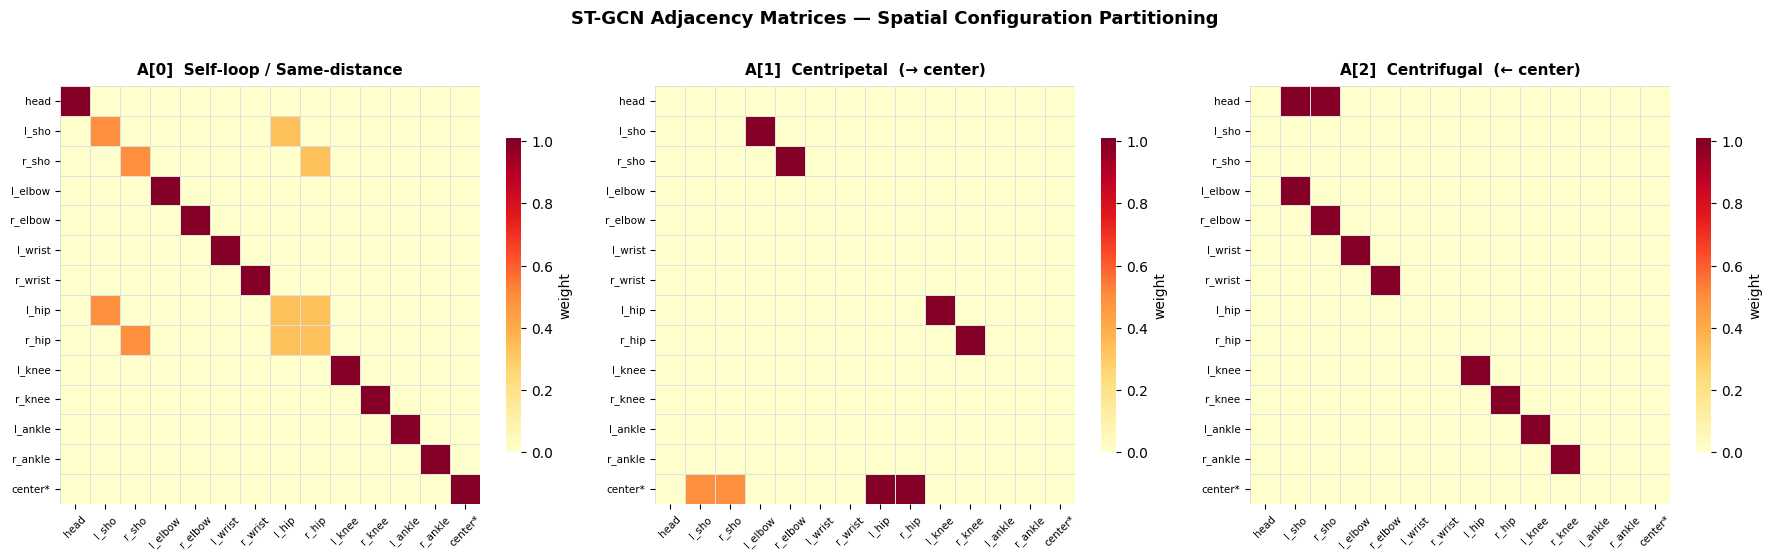

In [ ]:
# ── VIZ-1b: Adjacency matrix heatmaps (3 partitions) ────────────────────────
# Reuses: graph, JOINT_NAMES (from cell above)
A_np = graph.A.numpy()
titles = ['A[0]  Self-loop / Same-distance',
          'A[1]  Centripetal  (→ center)',
          'A[2]  Centrifugal  (← center)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('ST-GCN Adjacency Matrices — Spatial Configuration Partitioning',
             fontsize=13, fontweight='bold', y=1.01)

for k, ax in enumerate(axes):
    sns.heatmap(A_np[k], ax=ax, cmap='YlOrRd',
                xticklabels=JOINT_NAMES, yticklabels=JOINT_NAMES,
                linewidths=0.4, linecolor='#e0e0e0',
                vmin=0, vmax=A_np[k].max()+0.01,
                cbar_kws={'shrink': 0.75, 'label': 'weight'})
    ax.set_title(titles[k], fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=7.5)

plt.tight_layout()
plt.savefig('viz_adjacency_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import torch
import torch.nn as nn

class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True):
        super().__init__()
        # A lúc này có kích thước (3, V, V)
        self.spatial_kernel_size = A.size(0)
        self.A = nn.Parameter(A, requires_grad=False)

        # 1. Spatial GCN chuẩn: in_channels -> ra (out_channels * 3) để tương tác với 3 ma trận
        self.gcn_conv = nn.Conv2d(in_channels, out_channels * self.spatial_kernel_size, kernel_size=1)

        # 2. Temporal TCN (như cũ, kernel 9x1)
        self.tcn_conv = nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1),
                                  padding=(4, 0), stride=(stride, 1))

        # 3. Residual
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1))

        self.relu = nn.ReLU()

    def forward(self, x):
        res = self.residual(x)
        N, C, T, V = x.size()

        # --- SPATIAL CONVOLUTION CHUẨN ---
        x = self.gcn_conv(x) # (N, out_channels * 3, T, V)

        # Tách ra 3 luồng để nhân với 3 ma trận A (Root, Centripetal, Centrifugal)
        x = x.view(N, self.spatial_kernel_size, -1, T, V) # (N, 3, out_channels, T, V)

        # Dùng einsum để nhân từng đồ thị con với đặc trưng tương ứng
        x = torch.einsum('nkctv,kvw->nctw', (x, self.A)) # (N, out_channels, T, V)

        # --- TEMPORAL CONVOLUTION ---
        x = self.tcn_conv(x)

        return self.relu(x + res)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Model_STGCN(nn.Module):
    def __init__(self, num_classes=8, in_channels=2):
        super().__init__()
        # Khởi tạo đồ thị Penn Action
        self.graph = Graph_PennAction_14Nodes()
        A = self.graph.A

        # Data Normalization
        self.data_bn = nn.BatchNorm1d(in_channels * self.graph.num_node)

        # Các lớp ST-GCN (Thiết kế tinh gọn cho tập dữ liệu nhỏ)
        self.st_gcn_networks = nn.ModuleList([
            STGCN_Block(in_channels, 64, A, residual=False),
            STGCN_Block(64, 64, A),
            STGCN_Block(64, 128, A, stride=2), # Giảm số frame đi một nửa
            STGCN_Block(128, 128, A),
            STGCN_Block(128, 256, A, stride=2),
            STGCN_Block(256, 256, A)
        ])

        # Fully Connected Layer để phân loại
        self.fcn = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        # Kích thước đầu vào chuẩn của ST-GCN: (Batch, Channels, Frames, Joints, Persons)
        N, C, T, V, M = x.size()

        # Chuẩn hóa đầu vào
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M * V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)

        # Chạy qua các khối ST-GCN
        for gcn in self.st_gcn_networks:
            x = gcn(x)

        # Global Average Pooling (Lấy đặc trưng trung bình toàn cục)
        x = F.avg_pool2d(x, x.size()[2:])
        x = x.view(N, M, -1, 1, 1).mean(dim=1)

        # Đưa ra dự đoán
        x = self.fcn(x)
        x = x.view(x.size(0), -1)

        return x


In [ ]:

# Chạy thử để kiểm tra luồng dữ liệu (Sanity Check)
if __name__ == '__main__':
    # Giả lập đầu vào: Batch=4, Channels=2 (X,Y), Frames=64, Joints=13, Persons=1
    dummy_input = torch.randn(4, 2, 64, 14, 1)
    model = Model_STGCN(num_classes=8) # 8 lớp bài tập thể dục
    output = model(dummy_input)
    print(f"Kích thước tensor đầu ra: {output.shape} -> (Batch Size, Số lớp hành động)")

Kích thước tensor đầu ra: torch.Size([4, 8]) -> (Batch Size, Số lớp hành động)


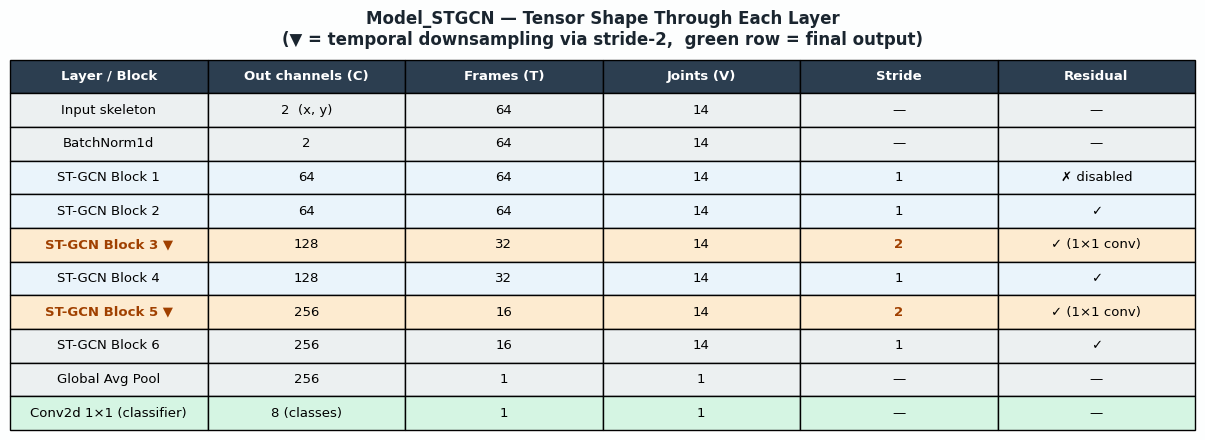

In [ ]:
# ── VIZ-3: Model architecture — tensor shape table ───────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis('off'); fig.patch.set_facecolor('#fdfefe')

columns = ['Layer / Block', 'Out channels (C)', 'Frames (T)', 'Joints (V)', 'Stride', 'Residual']
rows = [
    ['Input skeleton',          '2  (x, y)', '64', '14', '—', '—'],
    ['BatchNorm1d',             '2',          '64', '14', '—', '—'],
    ['ST-GCN Block 1',          '64',         '64', '14', '1', '✗ disabled'],
    ['ST-GCN Block 2',          '64',         '64', '14', '1', '✓'],
    ['ST-GCN Block 3 ▼',        '128',        '32', '14', '2', '✓ (1×1 conv)'],
    ['ST-GCN Block 4',          '128',        '32', '14', '1', '✓'],
    ['ST-GCN Block 5 ▼',        '256',        '16', '14', '2', '✓ (1×1 conv)'],
    ['ST-GCN Block 6',          '256',        '16', '14', '1', '✓'],
    ['Global Avg Pool',         '256',        '1',  '1',  '—', '—'],
    ['Conv2d 1×1 (classifier)', '8 (classes)','1',  '1',  '—', '—'],
]

table = ax.table(cellText=rows, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1.15, 2.0)

row_colors = {0:'#2c3e50', 1:'#ecf0f1', 2:'#ecf0f1', 3:'#eaf4fb', 4:'#eaf4fb',
              5:'#fdebd0', 6:'#eaf4fb', 7:'#fdebd0', 8:'#ecf0f1', 9:'#ecf0f1', 10:'#d5f5e3'}
for r, color in row_colors.items():
    for c in range(len(columns)):
        cell = table[(r, c)]
        cell.set_facecolor(color)
        if r == 0:
            cell.set_text_props(color='white', fontweight='bold')

for r in [5, 7]:
    table[(r, 0)].set_text_props(fontweight='bold', color='#a04000')
    table[(r, 4)].set_text_props(fontweight='bold', color='#a04000')

ax.set_title('Model_STGCN — Tensor Shape Through Each Layer\n'
             '(▼ = temporal downsampling via stride-2,  green row = final output)',
             fontsize=12, fontweight='bold', pad=18, color='#1a252f')
plt.tight_layout()
plt.savefig('viz_model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import os
import glob
import scipy.io
import numpy as np

# Corrected DATA_DIR to point to the downloaded dataset location
DATA_DIR   = os.path.join(DOWNLOAD_DIR, 'Penn_Action')
LABELS_DIR = os.path.join(DATA_DIR, 'labels')

TARGET_FRAMES = 64
exercise_classes = [
    'bench_press', 'clean_and_jerk', 'jump_rope', 'jumping_jacks',
    'pullup', 'pushup', 'situp', 'squat'
]
class_to_id = {cls_name: idx for idx, cls_name in enumerate(exercise_classes)}

def add_virtual_center_joint(kpts):
    l_sho, r_sho = kpts[:, 1, :], kpts[:, 2, :]
    l_hip, r_hip = kpts[:, 7, :], kpts[:, 8, :]
    center = (l_sho + r_sho + l_hip + r_hip) / 4.0
    return np.concatenate((kpts, center[:, np.newaxis, :]), axis=1)

def temporal_align(kpts, target_frames):
    T = kpts.shape[0]
    if T == target_frames:
        return kpts
    indices = np.linspace(0, T - 1, target_frames).astype(int)
    return kpts[indices]

all_data         = []
all_labels       = []
raw_frame_counts = []   # tracks original frame count before alignment (used by VIZ-2)

mat_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))
print(f"Scanning {len(mat_files)} files...")

for mat_file in mat_files:
    try:
        mat_data = scipy.io.loadmat(mat_file)
        action   = mat_data['action'][0] if 'action' in mat_data else 'unknown'
        if isinstance(action, np.ndarray) and len(action) > 0:
            action = action[0]
        action = str(action)
        if action not in exercise_classes:
            continue

        label_id = class_to_id[action]
        kpts     = np.stack((mat_data['x'], mat_data['y']), axis=-1)  # (T, 13, 2)

        raw_frame_counts.append(kpts.shape[0])               # save raw length

        kpts_aligned  = temporal_align(kpts, TARGET_FRAMES)
        kpts_14_nodes = add_virtual_center_joint(kpts_aligned)
        tensor_data   = np.expand_dims(np.transpose(kpts_14_nodes, (2, 0, 1)), axis=-1)  # (2,64,14,1)

        all_data.append(tensor_data)
        all_labels.append(label_id)
    except Exception as e:
        print(f"Skipping {os.path.basename(mat_file)}: {e}")

real_data_tensor   = np.array(all_data,   dtype=np.float32)
real_labels_tensor = np.array(all_labels, dtype=np.int64)

print(f"\nTotal samples : {len(real_labels_tensor)}")
print(f"Data shape    : {real_data_tensor.shape}  (N, C, T, V, M)")

np.save('penn_action_data_14nodes.npy', real_data_tensor)
np.save('penn_action_labels.npy',       real_labels_tensor)
print("Saved .npy files.")

Scanning 2326 files...

Total samples : 1163
Data shape    : (1163, 2, 64, 14, 1)  (N, C, T, V, M)
Saved .npy files.


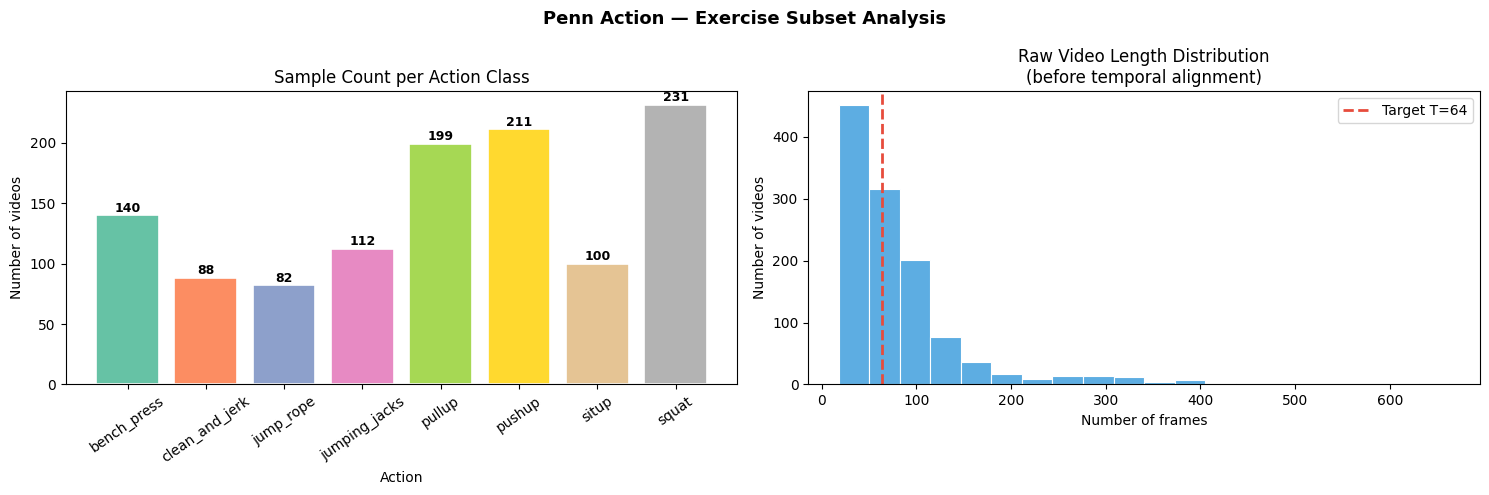

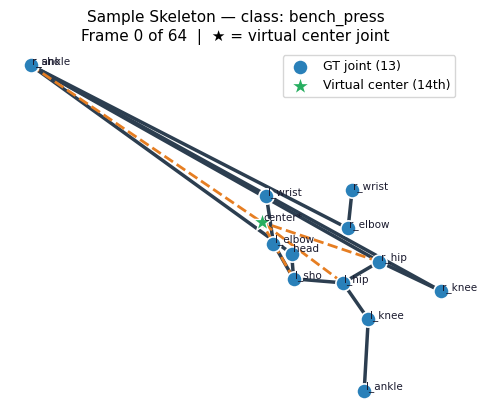

In [ ]:
# ── VIZ-2: Data statistics + sample skeleton ─────────────────────────────────
# Reuses: all_data, all_labels, raw_frame_counts, class_to_id, exercise_classes, JOINT_NAMES
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

id_to_class   = {v: k for k, v in class_to_id.items()}
label_counts  = Counter(all_labels)
counts_sorted = [label_counts[class_to_id[c]] for c in exercise_classes]
colors        = plt.cm.Set2(np.linspace(0, 1, len(exercise_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Penn Action — Exercise Subset Analysis', fontsize=13, fontweight='bold')

bars = axes[0].bar(exercise_classes, counts_sorted, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Sample Count per Action Class')
axes[0].set_xlabel('Action'); axes[0].set_ylabel('Number of videos')
axes[0].tick_params(axis='x', rotation=35)
for bar, cnt in zip(bars, counts_sorted):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].hist(raw_frame_counts, bins=20, color='#5dade2', edgecolor='white', linewidth=0.8)
axes[1].axvline(x=64, color='#e74c3c', linewidth=2, linestyle='--', label='Target T=64')
axes[1].set_title('Raw Video Length Distribution\n(before temporal alignment)')
axes[1].set_xlabel('Number of frames'); axes[1].set_ylabel('Number of videos')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_data_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sample skeleton: original 13 joints vs virtual center joint ──────────────
xy = all_data[0][:, 0, :, 0]   # (2, 14) from first sample, frame 0

edges_13      = [(0,1),(0,2),(1,3),(3,5),(2,4),(4,6),(1,7),(2,8),(7,8),(7,9),(9,11),(8,10),(10,12)]
edges_virtual = [(1,13),(2,13),(7,13),(8,13)]

fig, ax = plt.subplots(figsize=(5, 7))
ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
ax.set_title(f'Sample Skeleton — class: {id_to_class[all_labels[0]]}\n'
             f'Frame 0 of 64  |  ★ = virtual center joint', fontsize=11)

for (i, j) in edges_13:
    ax.plot([xy[0,i], xy[0,j]], [xy[1,i], xy[1,j]], color='#2c3e50', linewidth=2.5, zorder=1)
for (i, j) in edges_virtual:
    ax.plot([xy[0,i], xy[0,j]], [xy[1,i], xy[1,j]], color='#e67e22',
            linewidth=2.0, linestyle='--', zorder=1)

ax.scatter(xy[0,:13], xy[1,:13], s=120, color='#2980b9', zorder=3,
           edgecolors='white', linewidths=1.2, label='GT joint (13)')
ax.scatter(xy[0,13],  xy[1,13],  s=200, color='#27ae60', marker='*', zorder=4,
           edgecolors='white', linewidths=1.0, label='Virtual center (14th)')

for i in range(14):
    ax.text(xy[0,i]+1, xy[1,i]-1, JOINT_NAMES[i], fontsize=7.5, color='#1a1a2e', zorder=5)

ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('viz_sample_skeleton.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import numpy as np

# Đảm bảo sử dụng GPU trên Kaggle nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# ==========================================
# 1. ĐỊNH NGHĨA DATASET (Khuôn mẫu)
# ==========================================
class PennActionDataset(Dataset):
    def __init__(self, data_tensor, label_tensor):
        """
        data_tensor: Kích thước (Số video, 2, Số frame cố định, 14, 1) -> (N, C, T, V, M)
        label_tensor: Kích thước (Số video,) chứa ID lớp hành động (0 đến 7)
        """
        self.data = torch.FloatTensor(data_tensor)
        self.labels = torch.LongTensor(label_tensor)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
from sklearn.model_selection import train_test_split

# 1. Load dữ liệu THẬT
real_data = np.load('penn_action_data_14nodes.npy')
real_labels = np.load('penn_action_labels.npy')

# 2. Chia tập Train / Val thực tế (Tỷ lệ 80-20) bằng scikit-learn
X_train, X_val, y_train, y_val = train_test_split(
    real_data, real_labels, test_size=0.2, random_state=42, stratify=real_labels
)

# 3. Nạp vào Dataset
train_dataset = PennActionDataset(X_train, y_train)
val_dataset = PennActionDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Đang sử dụng thiết bị: cuda


In [ ]:
print(len(train_dataset), len(val_dataset))
# len(train_dataset)

930 233


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the target directory within your Google Drive
# This will create a folder named 'Colab_STGCN_Weights' directly in your 'My Drive'.
# If you intend to save to a specific shared folder, you might need to manually create
# a shortcut to that shared folder within your 'My Drive' and adjust this path accordingly.
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Colab_STGCN_Weights'

os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"Google Drive save directory: {DRIVE_SAVE_DIR}")

Google Drive save directory: /content/drive/MyDrive/Colab_STGCN_Weights


Epoch [  1/80]  Train Loss: 1.9400  Acc: 0.3022  |  Val Loss: 1.5813  Acc: 0.4034  F1: 0.2789
Epoch [  2/80]  Train Loss: 1.4295  Acc: 0.4624  |  Val Loss: 1.0380  Acc: 0.6137  F1: 0.4881
Epoch [  3/80]  Train Loss: 1.4561  Acc: 0.5226  |  Val Loss: 7.8330  Acc: 0.3176  F1: 0.1828
Epoch [  4/80]  Train Loss: 1.7434  Acc: 0.4011  |  Val Loss: 1.0906  Acc: 0.5880  F1: 0.5036
Epoch [  5/80]  Train Loss: 1.2099  Acc: 0.5892  |  Val Loss: 1.0997  Acc: 0.6052  F1: 0.5625
Epoch [  6/80]  Train Loss: 1.4742  Acc: 0.5258  |  Val Loss: 1.0214  Acc: 0.6309  F1: 0.5579
Epoch [  7/80]  Train Loss: 1.1075  Acc: 0.6839  |  Val Loss: 1.0794  Acc: 0.5966  F1: 0.5813
Epoch [  8/80]  Train Loss: 1.1083  Acc: 0.6000  |  Val Loss: 0.8285  Acc: 0.7210  F1: 0.6622
Epoch [  9/80]  Train Loss: 0.9910  Acc: 0.7097  |  Val Loss: 0.6213  Acc: 0.8026  F1: 0.7732
Epoch [ 10/80]  Train Loss: 0.7442  Acc: 0.7774  |  Val Loss: 0.5044  Acc: 0.8197  F1: 0.8022
Epoch [ 11/80]  Train Loss: 0.6111  Acc: 0.8355  |  Val Loss

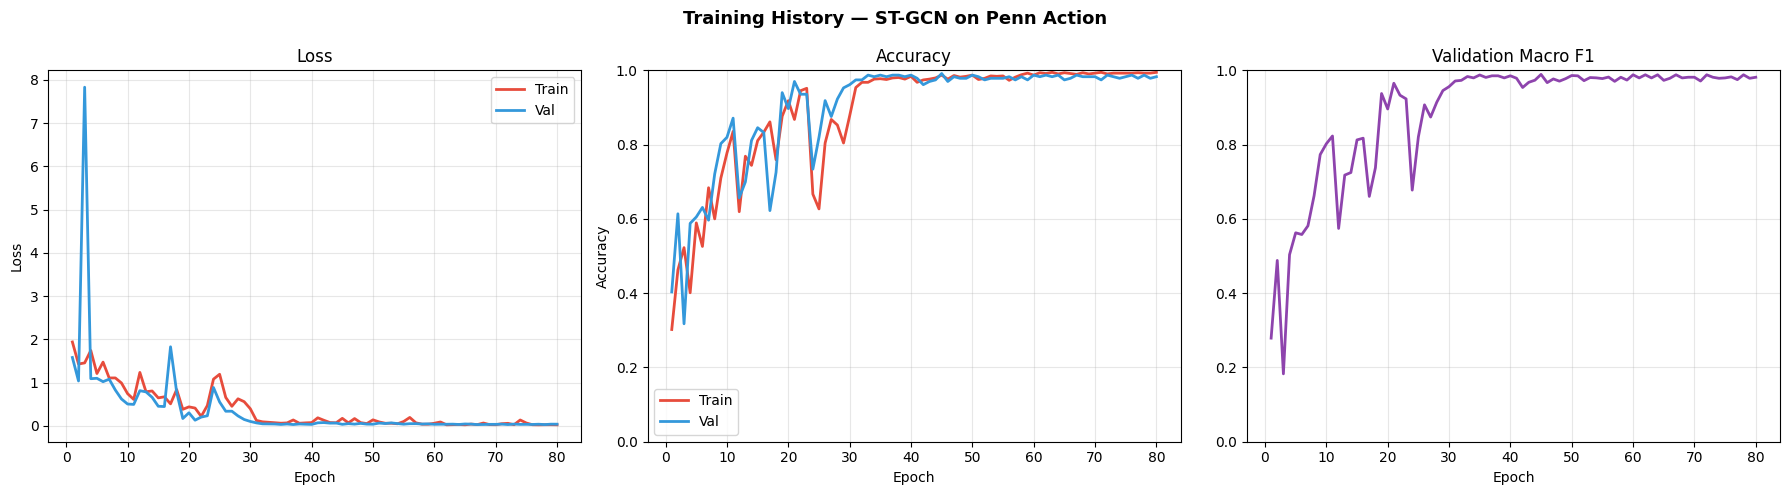

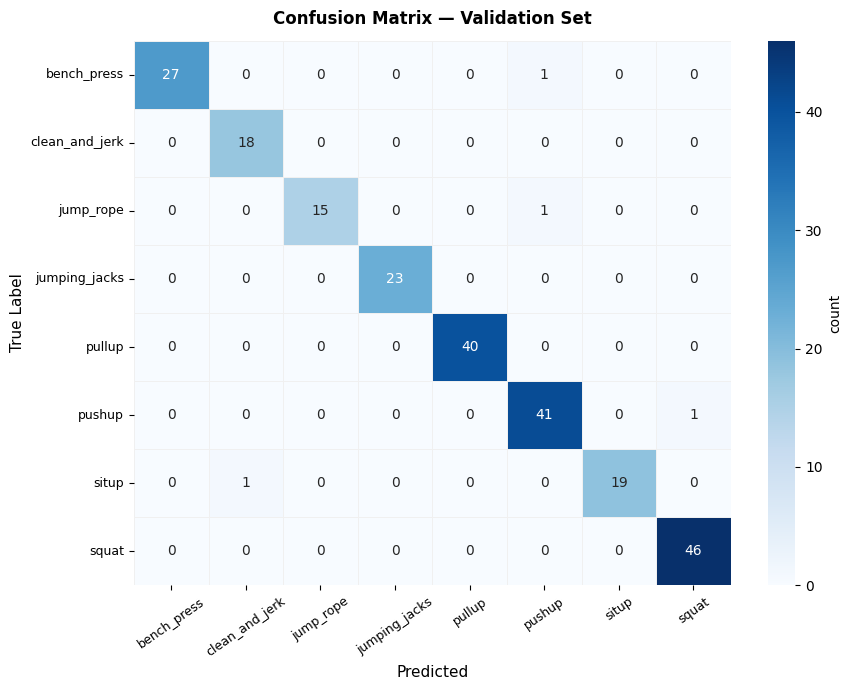

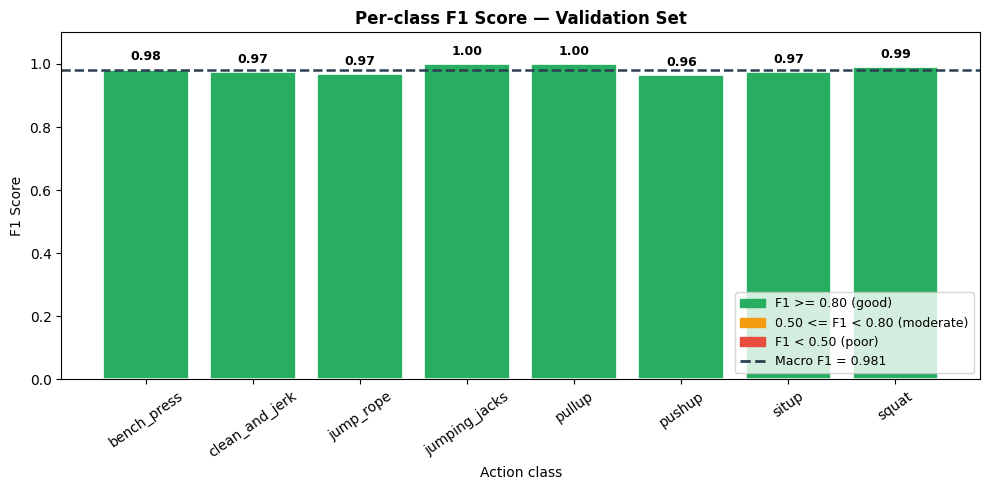


--- Classification Report ---
                precision    recall  f1-score   support

   bench_press       1.00      0.96      0.98        28
clean_and_jerk       0.95      1.00      0.97        18
     jump_rope       1.00      0.94      0.97        16
 jumping_jacks       1.00      1.00      1.00        23
        pullup       1.00      1.00      1.00        40
        pushup       0.95      0.98      0.96        42
         situp       1.00      0.95      0.97        20
         squat       0.98      1.00      0.99        46

      accuracy                           0.98       233
     macro avg       0.98      0.98      0.98       233
  weighted avg       0.98      0.98      0.98       233



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (f1_score, accuracy_score,
                             confusion_matrix, classification_report)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# __ Init ───────────────────────────────────────────────────────────────────
model     = Model_STGCN(num_classes=8, in_channels=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

num_epochs = 80   # set to 5 for a quick smoke-test

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

# __ Training loop ──────────────────────────────────────────────────────────
for epoch in range(num_epochs):
    model.train()
    total_loss, preds_tr, lbls_tr = 0, [], []
    for batch_data, batch_labels in train_loader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        out  = model(batch_data)
        loss = criterion(out, batch_labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        _, p = torch.max(out, 1)
        preds_tr.extend(p.cpu().numpy()); lbls_tr.extend(batch_labels.cpu().numpy())
    scheduler.step()

    model.eval()
    val_loss, preds_val, lbls_val = 0, [], []
    with torch.no_grad():
        for batch_data, batch_labels in val_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            out  = model(batch_data)
            loss = criterion(out, batch_labels)
            val_loss += loss.item()
            _, p = torch.max(out, 1)
            preds_val.extend(p.cpu().numpy()); lbls_val.extend(batch_labels.cpu().numpy())

    tr_acc  = accuracy_score(lbls_tr,  preds_tr)
    val_acc = accuracy_score(lbls_val, preds_val)
    val_f1  = f1_score(lbls_val, preds_val, average='macro', zero_division=0)

    history['train_loss'].append(total_loss / len(train_loader))
    history['val_loss'].append(val_loss     / len(val_loader))
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch [{epoch+1:3d}/{num_epochs}]  "
          f"Train Loss: {history['train_loss'][-1]:.4f}  Acc: {tr_acc:.4f}  |  "
          f"Val Loss: {history['val_loss'][-1]:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}")

# Save the model to Google Drive
model_save_path = os.path.join(DRIVE_SAVE_DIR, 'stgcn_penn_action.pth')
torch.save(model.state_dict(), model_save_path)
print(f"Model saved: {model_save_path}")

# __ VIZ-4a: Training curves ───────────────────────────────────────────────
ep = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — ST-GCN on Penn Action', fontsize=13, fontweight='bold')

axes[0].plot(ep, history['train_loss'], label='Train', color='#e74c3c', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#3498db', linewidth=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', color='#e74c3c', linewidth=2)
axes[1].plot(ep, history['val_acc'],   label='Val',   color='#3498db', linewidth=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_f1'], color='#8e44ad', linewidth=2)
axes[2].set_title('Validation Macro F1'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# __ VIZ-4b: Confusion matrix ──────────────────────────────────────────────
conf_mat = confusion_matrix(lbls_val, preds_val)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=exercise_classes, yticklabels=exercise_classes,
            linewidths=0.5, linecolor='#f0f0f0', ax=ax,
            cbar_kws={'label': 'count'})
ax.set_title('Confusion Matrix — Validation Set', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('viz_confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()

# __ VIZ-4c: Per-class F1 bar chart ───────────────────────────────────────
f1_per_class = f1_score(lbls_val, preds_val, average=None, zero_division=0)
bar_colors   = ['#27ae60' if f>=0.8 else '#f39c12' if f>=0.5 else '#e74c3c'
                for f in f1_per_class]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(exercise_classes, f1_per_class, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.axhline(y=np.mean(f1_per_class), color='#2c3e50', linewidth=1.8, linestyle='--')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Score — Validation Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Action class'); ax.set_ylabel('F1 Score')
ax.tick_params(axis='x', rotation=35)
for bar, f in zip(bars, f1_per_class):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{f:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(handles=[
    Patch(color='#27ae60', label='F1 >= 0.80 (good)'),
    Patch(color='#f39c12', label='0.50 <= F1 < 0.80 (moderate)'),
    Patch(color='#e74c3c', label='F1 < 0.50 (poor)'),
    plt.Line2D([0],[0], color='#2c3e50', linewidth=2, linestyle='--',
               label=f'Macro F1 = {np.mean(f1_per_class):.3f}'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('viz_per_class_f1.png', dpi=150, bbox_inches='tight'); plt.show()

print("\n--- Classification Report ---")
print(classification_report(lbls_val, preds_val,
                             target_names=exercise_classes, zero_division=0))